In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import shap
import lime

import joblib

In [2]:
def plot_confusion_matrix(y_true, y_pred, model_name="Model", figsize=(8, 6)):
    """
    Create a nice confusion matrix visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred: predicted labels  
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.colorbar()
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    
    # Add labels
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    plt.yticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    
    # Calculate and display accuracy
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    plt.suptitle(f'Accuracy: {accuracy:.3f}', fontsize=14, y=0.02)
    
    plt.tight_layout()
    plt.show()

     # Print detailed metrics
    print(f"\n{model_name} Performance:")
    print(f"True Negatives: {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives: {cm[1,1]}")
    print(f"Accuracy: {accuracy:.3f}")
    
    # Calculate additional metrics
    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    
    return cm, accuracy

In [3]:
def plot_roc_curve(y_true, y_pred_proba, model_name="Model", figsize=(8, 6)):
    """
    Create a nice ROC curve visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred_proba: predicted probabilities (for positive class)
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc_score = roc_auc_score(y_true, y_pred_proba)
    
    plt.figure(figsize=figsize)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'{model_name} (AUC = {auc_score:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.500)')
    
    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - ROC Curve', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print AUC score
    print(f"\n{model_name} ROC AUC Score: {auc_score:.3f}")
    
    # Interpretation
    if auc_score > 0.9:
        print("Excellent performance!")
    elif auc_score > 0.8:
        print("Good performance!")
    elif auc_score > 0.7:
        print("Fair performance")
    elif auc_score > 0.6:
        print("Poor performance")
    else:
        print("Very poor performance")
    
    return fpr, tpr, auc_score

In [4]:
def plot_feature_importance(model, feature_names, model_name="Model", figsize=(10, 6)):
    """
    Plot feature importance for tree-based models
    
    Parameters:
    model: trained tree-based model (e.g., DecisionTreeClassifier, RandomForestClassifier)
    feature_names: list of feature names
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=figsize)
    plt.title(f'{model_name} - Feature Importances', fontsize=16, fontweight='bold')
    plt.bar(range(len(importances)), importances[indices], align='center', color='skyblue')
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90, fontsize=10)
    plt.ylabel('Importance Score', fontsize=12, fontweight='bold')
    plt.xlabel('Features', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print feature importance scores
    print(f"\n{model_name} Feature Importances:")
    for i in indices:
        print(f"{feature_names[i]}: {importances[i]:.4f}")

In [5]:
data = pd.read_csv('/kaggle/input/heart-prediction-preprocessed/heart_preprocessed_scaled.csv')

In [6]:
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
params = {
    'n_estimators': [100, 200, 300],  # Reduced from 4 to 3
    'criterion': ['gini', 'entropy'],  # Removed 'log_loss' (similar to entropy)
    'max_depth': [None, 10, 20],  # Reduced from 5 to 3 (kept most important)
    'min_samples_split': [2, 5],  # Reduced from 3 to 2
    'min_samples_leaf': [1, 2],  # Reduced from 3 to 2
    'max_features': ['sqrt', 'log2'],  # Removed None
    'bootstrap': [True],  # Keep True (standard for RF)
    'random_state': [42],
    'n_jobs' : [-1]
}

rfc = RandomForestClassifier()
grid_rfc = GridSearchCV(rfc, param_grid=params, cv=5, scoring='f1', verbose=1)
grid_rfc.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True], 'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300], 'n_jobs': [-1],
                         'random_state': [42]},
             scoring='f1', verbose=1)

In [8]:
print(f"Best parameters: {grid_rfc.best_params_}")
print(f"Best cross-validation score: {grid_rfc.best_score_}")

Best parameters: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
Best cross-validation score: 0.8839286914604518


In [9]:
rfc_pred = grid_rfc.predict(X_test)

In [10]:
print(classification_report(y_test, rfc_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88        82
           1       0.90      0.91      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184



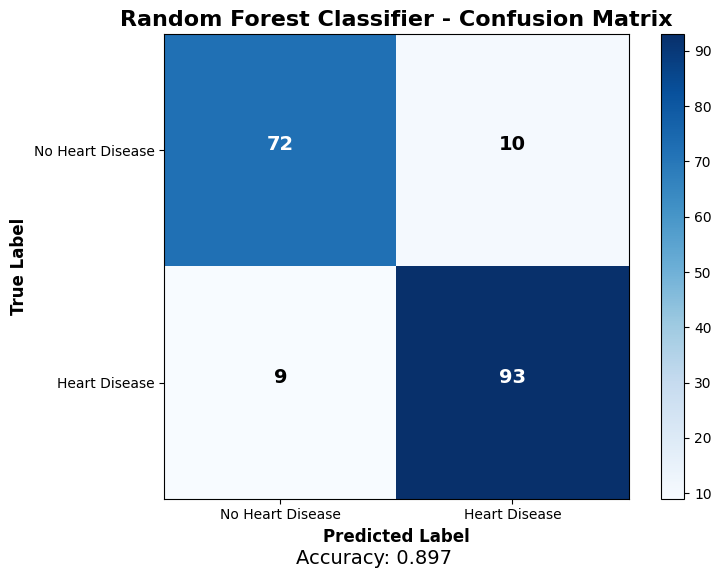


Random Forest Classifier Performance:
True Negatives: 72
False Positives: 10
False Negatives: 9
True Positives: 93
Accuracy: 0.897
Precision: 0.903
Recall: 0.912
F1-Score: 0.907


In [11]:
rfc_cm, rfc_acc = plot_confusion_matrix(y_test, rfc_pred, 'Random Forest Classifier')

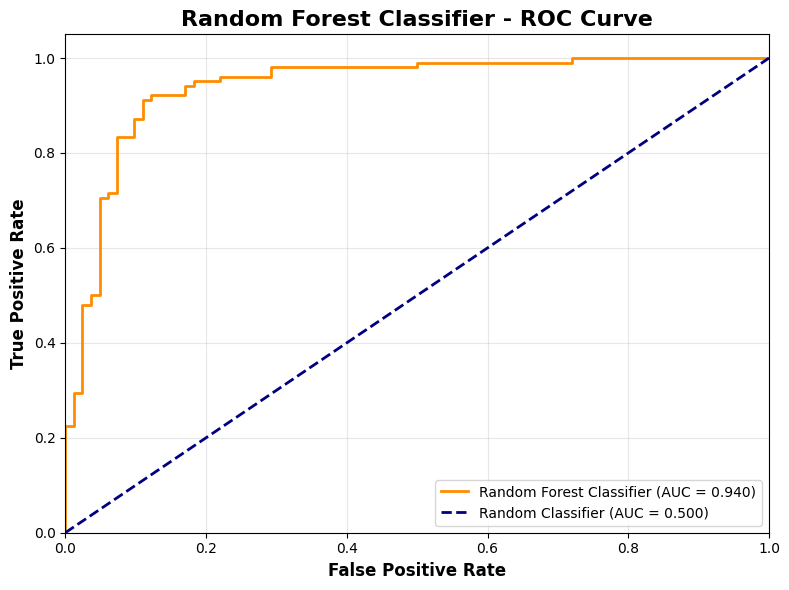


Random Forest Classifier ROC AUC Score: 0.940
Excellent performance!


In [12]:
rfc_proba = grid_rfc.predict_proba(X_test)[:, 1]
rfc_fpr, rfc_tpr, rfc_thresholds = plot_roc_curve(y_test, rfc_proba, 'Random Forest Classifier')

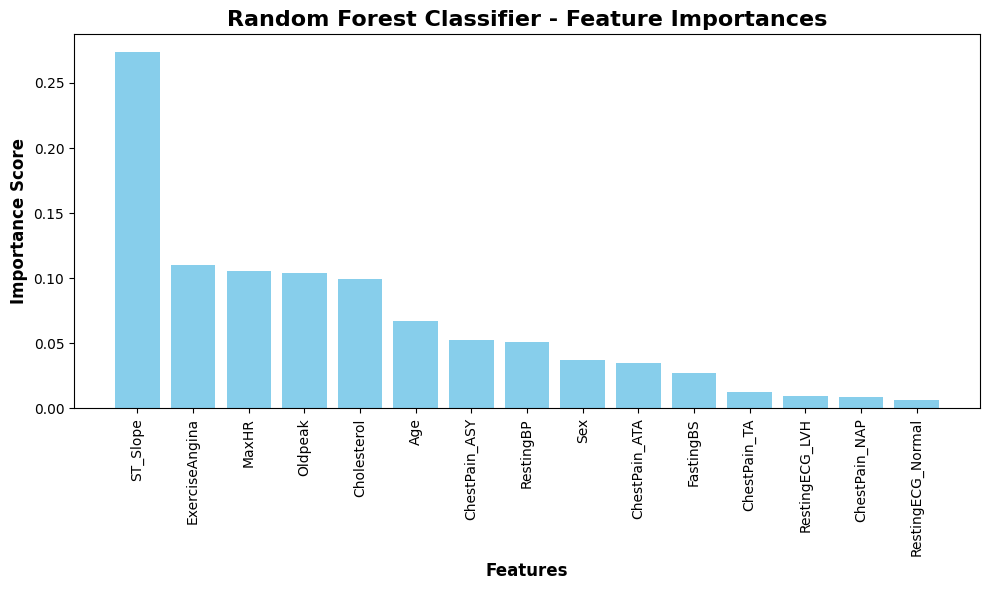


Random Forest Classifier Feature Importances:
ST_Slope: 0.2737
ExerciseAngina: 0.1102
MaxHR: 0.1056
Oldpeak: 0.1037
Cholesterol: 0.0998
Age: 0.0669
ChestPain_ASY: 0.0524
RestingBP: 0.0507
Sex: 0.0370
ChestPain_ATA: 0.0348
FastingBS: 0.0271
ChestPain_TA: 0.0128
RestingECG_LVH: 0.0098
ChestPain_NAP: 0.0090
RestingECG_Normal: 0.0064


In [13]:
plot_feature_importance(grid_rfc.best_estimator_, X.columns, model_name="Random Forest Classifier")

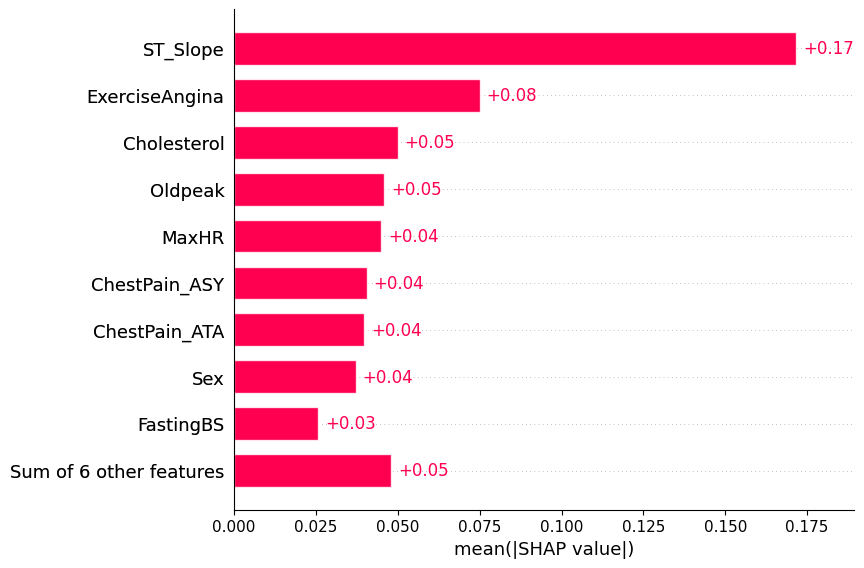

In [14]:
explainer = shap.TreeExplainer(grid_rfc.best_estimator_)
shap_values = explainer.shap_values(X_test)

# shap_values from KernelExplainer can be a list (one array per class) or a 3D numpy array
# with shape (n_samples, n_features, n_classes). Select the positive class (index 1)
# and wrap into a shap.Explanation so shap.plots.bar accepts it.
class_idx = 1

if isinstance(shap_values, list):
	values = shap_values[class_idx]
elif hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
	values = shap_values[..., class_idx]
else:
	# fallback: assume shap_values already in the desired 2D shape
	values = shap_values

base_values = explainer.expected_value[class_idx] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value

shap_exp = shap.Explanation(values=values, base_values=base_values, data=X_test, feature_names=X_test.columns)
shap.plots.bar(shap_exp)

In [15]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(training_data=X_train.values, feature_names=X_train.columns, class_names=['No Heart Disease', 'Heart Disease'], mode='classification')
i = 180
exp = lime_explainer.explain_instance(data_row=X_test.values[i], predict_fn=grid_rfc.predict_proba)
exp.show_in_notebook(show_table=True)

X does not have valid feature names, but RandomForestClassifier was fitted with feature names


In [16]:
joblib.dump(grid_rfc, '/kaggle/working/random_forest_model.pkl')

['/kaggle/working/random_forest_model.pkl']